In [6]:
title = "# Probabilities: Exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
#import bayesian_stats_course_tools
#bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

OSError: 'bayesian_stats_course_tools.light' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## Overview

Both exercises below are classic probability puzzles that are notorious for being unintuitive at first glance. For each one, you will:

1. Work out the probability **analytically**, using the definition of conditional probability and/or Bayes' theorem.
2. Check your answer with a **Monte-Carlo simulation**.

Getting the same answer from both directions is a good way to build confidence that you understand *why* the result holds, not just that you can reproduce a formula.

---
## Exercise 0: Warm-up — dice, sets, and Bayes' theorem

Before the two main exercises, a few short questions to refresh the concepts from the lecture: sample spaces, independence, and Bayes' theorem. These are quick — a couple of lines of code or algebra each.

1. Two fair six-sided dice are rolled. Enumerate the sample space $\Omega$ of the 36 equally-likely $(d_1, d_2)$ outcomes (e.g. with `itertools.product`), and use it to compute $P(\text{sum} = 7)$.
2. Let $A$ be "the sum is 7" and $B$ be "at least one die shows a 4". Are $A$ and $B$ independent? Check using $P(A \mid B) \overset{?}{=} P(A)$.
3. A rare disease affects 0.1% of the population. A test for it is 99% accurate on people who have it, and gives a false positive 2% of the time on people who don't. Using Bayes' theorem, what is $P(\text{disease} \mid \text{positive test})$?

> **Hint.** For question 3: $P(D \mid {+}) = \dfrac{P(+ \mid D)P(D)}{P(+ \mid D)P(D) + P(+ \mid D^c)P(D^c)}$ — the denominator is the law of total probability applied to $\{D, D^c\}$. The answer is smaller than most people expect; that's the point.


In [ ]:
# Your code here: work through questions 1-3 above



In [2]:
P_D = 0.001

#implies
P_nD = 1 - P_D

P_pos_given_D = 0.99

P_pos_given_nD = 0.02

P_pos = P_D * P_pos_given_D + P_nD * P_pos_given_nD

P_D_given_pos = P_pos_given_D * P_D / P_pos

P_D_given_pos

0.047210300429184546

---
## Exercise 1: The birthday problem

**Question.** What is the probability that at least two people in this room share a birthday?

More precisely: let $B_n$ be the event that at least two people out of $n$ share a birthday. Find $P(B_n)$.

**Assumptions:**
- Birthdays are independent between people.
- Every day of the year is equally likely to be someone's birthday.
- The year has 365 days (ignore leap years).

#### Your analytic derivation

*(Write your derivation of $P(B_n)$ here, e.g. using LaTeX in this markdown cell.)*

In [14]:
# Your code here: implement P(B_n) and evaluate it for n = 17 and n = 23

def pr_bn(n, days = 365):
    probs = np.zeros(n)
    for i in range(1,n+1):
        probs[i-1] = (days-i+1)/days
    pr = np.prod(probs)
    return 1-pr

print(f'P(B_n) for n = 17: {pr_bn(17)}')
print(f'P(B_n) for n = 23: {pr_bn(23)}')

P(B_n) for n = 17: 0.3150076652965609
P(B_n) for n = 23: 0.5072972343239857


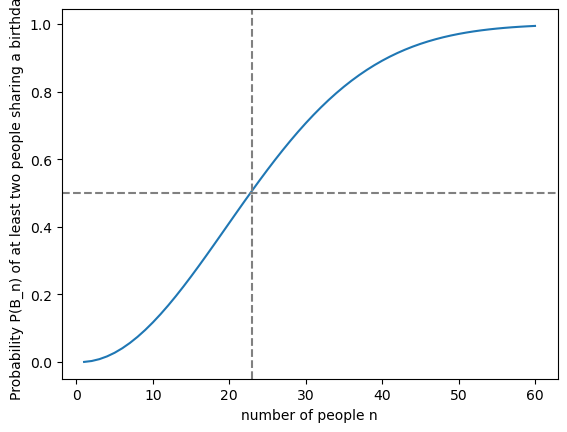

In [39]:
# Your code here: plot P(B_n) as a function of n
n = 60
n_arr = np.linspace(1, n, n)
probs = np.zeros(n)

for i in range(1,n+1):
    probs[i-1] = pr_bn(i)

plt.plot(n_arr, probs)
plt.xlabel('number of people n')
plt.ylabel('Probability P(B_n) of at least two people sharing a birthday')
plt.axhline(0.5, color = 'gray', linestyle = '--')
plt.axvline(23, color = 'gray', linestyle = '--')

---
## Exercise 2: The Monty Hall problem

**Setup.** In a game show, a contestant is presented with three doors. Behind one door is a car, and behind the other two are goats. The goal is to win the car.

The game proceeds as follows:
1. The contestant chooses a door, which stays closed for now.
2. The host, who knows where the car is, opens one of the *other two* doors, always revealing a goat.
3. The contestant may now **stick** with their original door, or **switch** to the remaining closed door.

Let $M$ denote this hypothesis — the rules of the game exactly as just described (in particular: the car is placed uniformly at random behind one of the three doors, and the host, who knows where it is, always opens one of the remaining doors to reveal a goat). We'll write $M$ explicitly in the probabilities below, as a reminder that the answer follows from these specific rules of the game, not from the numbers "3 doors" alone.

**Question.** What is the best strategy? Concretely, suppose the contestant first chooses door 1 and the host opens door 3 (revealing a goat). What is $P(C_1 \mid H_3, M)$, the probability of winning by sticking, versus $P(C_2 \mid H_3, M)$, the probability of winning by switching?

### Task

You are free to tackle these two parts in either order — each is a useful check on the other.

**A. Simulate the game.**
1. Write a function that plays one round: randomly place the car, have the contestant pick a door, have the host open a door with a goat behind it (excluding the contestant's door and the car's door), and record whether *sticking* or *switching* would have won.
2. Repeat for many rounds (e.g. $10^5$) and estimate $P(\text{win} \mid \text{stick}, M)$ and $P(\text{win} \mid \text{switch}, M)$ from the simulated frequencies.

**B. Derive it analytically.**
1. Write out $P(C_1 \mid H_3, M)$ using Bayes' theorem:
$$P(C_1 \mid H_3, M) = \frac{P(H_3 \mid C_1, M)\,P(C_1 \mid M)}{P(H_3 \mid M)}$$
2. Work out each ingredient: the prior $P(C_i \mid M)$ for each door, and the likelihood $P(H_3 \mid C_i, M)$ for each door (i.e. how likely is the host to open door 3, given where the car actually is, under the rules $M$?).
3. Expand the denominator $P(H_3 \mid M)$ by summing over the three possible car locations, and put everything together.
4. Compare $P(C_1 \mid H_3, M)$ and $P(C_2 \mid H_3, M)$ to your simulated estimates from part A.

> **Hint.** The denominator $P(H_3 \mid M)$ is the same for both $P(C_1\mid H_3, M)$ and $P(C_2\mid H_3, M)$. If you only care about *which* strategy is better, you can sidestep computing it entirely by looking at the posterior odds $P(C_2 \mid H_3, M) / P(C_1 \mid H_3, M)$ instead.

> **Bonus.** How do the winning probabilities change if there are $N > 3$ doors, with the host still opening $N - 2$ goat-doors one at a time before offering the switch? (This changes the rules to a new hypothesis $M_N$.)

In [ ]:
# Your code here: simulate the Monty Hall game and estimate
# P(win | stick) and P(win | switch)


#### Your analytic derivation

*(Write your derivation of $P(C_1 \mid H_3, M)$ and $P(C_2 \mid H_3, M)$ here.)*